<a href="https://colab.research.google.com/github/Chen-M-22/GridCast/blob/main/04_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transformer Forecasting

This notebook develops a Transformer model for short-term ERCOT electricity demand forecasting. Using the previous 168 hours of demand, the model predicts the following 24 hours and is evaluated on the 2024 validation period against the seasonal baselines established previously.

In [1]:
import pandas as pd
import numpy as np
import keras
from keras import layers
import matplotlib.pyplot as plt

In [2]:
historical_demand_df = pd.read_csv('ercot_hourly_demand_2020_2025_clean.csv', parse_dates=['timestamp'])

In [3]:
historical_demand_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52608 entries, 0 to 52607
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  52608 non-null  datetime64[ns]
 1   demand     52608 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 822.1 KB


In [4]:
historical_demand_df.isna().sum()

,0
timestamp,0
demand,0


In [5]:
historical_demand_df['timestamp'].duplicated().sum()

np.int64(0)

In [6]:
historical_demand_df.head()

,timestamp,demand
0,2020-01-01 00:00:00,40020.0
1,2020-01-01 01:00:00,41642.0
2,2020-01-01 02:00:00,40925.0
3,2020-01-01 03:00:00,39980.0
4,2020-01-01 04:00:00,39165.0


In [7]:
historical_demand_df.tail()

,timestamp,demand
52603,2025-12-31 19:00:00,49656.0
52604,2025-12-31 20:00:00,48726.0
52605,2025-12-31 21:00:00,48059.0
52606,2025-12-31 22:00:00,48037.0
52607,2025-12-31 23:00:00,48403.0


In [8]:
historical_demand_df['timestamp'].is_monotonic_increasing

True

##Time Series Data Generation and Data Split

In [9]:
input_length = 168
horizon = 24

x = []
y = []

target_start_times = []
target_end_times = []

for i in range (input_length, len(historical_demand_df) - horizon + 1):
  x.append(historical_demand_df['demand'].iloc[i-input_length: i].to_numpy())
  y.append(historical_demand_df['demand'].iloc[i: i + horizon].to_numpy())

  target_start_times.append(historical_demand_df['timestamp'].iloc[i])
  target_end_times.append(historical_demand_df['timestamp'].iloc[i + horizon - 1])

target_start_times = pd.Series(target_start_times)
target_end_times = pd.Series(target_end_times)

train_mask = target_end_times < pd.Timestamp('2024-01-01')
val_mask = (target_start_times >= pd.Timestamp('2024-01-01')) & (target_end_times < pd.Timestamp('2025-01-01'))
test_mask = (target_start_times >= pd.Timestamp('2025-01-01'))

x = np.array(x)
y = np.array(y)

x_train = x[train_mask]
y_train = y[train_mask]

x_val = x[val_mask]
y_val = y[val_mask]

x_test = x[test_mask]
y_test = y[test_mask]

In [10]:
print('Total Windows:', len(x))
print('Total Train:', train_mask.sum())
print('Total Validation:', val_mask.sum())
print('Total Test:', test_mask.sum())
print('Excluded:', len(x) - train_mask.sum() - val_mask.sum() - test_mask.sum())
print('\n')
print('Train Dataset:', x_train.shape, y_train.shape)
print('Validation Dataset:', x_val.shape, y_val.shape)
print('Test Dataset:', x_test.shape, y_test.shape)

Total Windows: 52417
Total Train: 34873
Total Validation: 8761
Total Test: 8737
Excluded: 46


Train Dataset: (34873, 168) (34873, 24)
Validation Dataset: (8761, 168) (8761, 24)
Test Dataset: (8737, 168) (8737, 24)


##Data Standardization

In [11]:
train_demand = historical_demand_df[historical_demand_df['timestamp'] < pd.Timestamp('2024-01-01')]['demand']
train_mean = train_demand.mean()
train_std = train_demand.std()

x_train_scaled = (x_train - train_mean) / train_std
y_train_scaled = (y_train - train_mean) / train_std

x_val_scaled = (x_val - train_mean) / train_std
y_val_scaled = (y_val - train_mean) / train_std

x_test_scaled = (x_test - train_mean) / train_std
y_test_scaled = (y_test - train_mean) / train_std

In [12]:
len(train_demand)
print('training data mean:', train_mean)
print('training data standard deviation:', train_std)
print('\n')

print(x_train_scaled.shape, y_train_scaled.shape)
print(x_val_scaled.shape, y_val_scaled.shape)

print(np.isnan(x_train_scaled).sum())
print(np.isinf(x_train_scaled).sum())

training data mean: 47083.72900981063
training data standard deviation: 10754.099125300023


(34873, 168) (34873, 24)
(8761, 168) (8761, 24)
0
0


##Transformer

In [13]:
# Convert input data to (samples, timesteps, features).
# x has one feature, demand.

x_train_transformer = x_train_scaled[:, :, np.newaxis]
x_val_transformer = x_val_scaled[:, :, np.newaxis]
x_test_transformer = x_test_scaled[:, :, np.newaxis]

In [14]:
print(x_train_transformer.shape, x_val_transformer.shape, x_test_transformer.shape)

(34873, 168, 1) (8761, 168, 1) (8737, 168, 1)


In [28]:
class PositionEmbedding(keras.Layer):
  def __init__(self, sequence_length, output_dim):
    super().__init__()
    self.position_embeddings = layers.Embedding(input_dim = sequence_length, output_dim = output_dim)

  def call(self, inputs):
    positions = keras.ops.arange(0, keras.ops.shape(inputs)[1])
    embedded_positions = self.position_embeddings(positions)
    return embedded_positions

In [31]:
sequence_length = 168
features = 1
hidden_dim = 32
num_heads = 4
key_dim = hidden_dim // num_heads
feedforward_dim = 64
pred_length = 24

inputs = keras.Input(shape=(sequence_length, features))
t = layers.Dense(units=hidden_dim)(inputs)

# add position embedding

embedded_positions = PositionEmbedding(sequence_length=sequence_length, output_dim=hidden_dim)(t)
t = t + embedded_positions

# multi head attention
multi_head_attention_outputs = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(query=t, key=t, value=t)
t = t + multi_head_attention_outputs
t = layers.LayerNormalization()(t)

# feedforward
feedforward_outputs = layers.Dense(units=feedforward_dim, activation='relu')(t)
feedforward_outputs = layers.Dense(units=hidden_dim)(feedforward_outputs)
t = t + feedforward_outputs
t = layers.LayerNormalization()(t)

# outputs
t = t[:, -1, :] # (B, T, H) -> (B, H), use the final contextual representation, which summarizes info from the full input sequence.
outputs = layers.Dense(units=pred_length)(t)

transformer_model = keras.Model(inputs = inputs, outputs = outputs)

In [32]:
transformer_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 168, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 168, 32)   │         64 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_embedding… │ (168, 32)         │      5,376 │ dense_25[0][0]    │
│ (PositionEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_17 (Add)        │ (None, 168, 32)   │          0 │ dense_25[0][0],   │
│                     │                   │            │ position_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 168, 32)   │      4,224 │ add_17[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_17[0][0],     │
│                     │                   │            │ add_17[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, 168, 32)   │          0 │ add_17[0][0],     │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 168, 32)   │         64 │ add_18[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 168, 64)   │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 168, 32)   │      2,080 │ dense_26[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_19 (Add)        │ (None, 168, 32)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_27[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 168, 32)   │         64 │ add_19[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_6          │ (None, 32)        │          0 │ layer_normalizat… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 24)        │        792 │ get_item_6[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,776 (57.72 KB)

 Trainable params: 14,776 (57.72 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
transformer_model.compile(
    optimizer = 'adam',
    loss = 'mse',
    metrics = ['mae']
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    restore_best_weights = True
)

model_check = keras.callbacks.ModelCheckpoint(
    filepath = 'best_transformer.weights.h5',
    monitor = 'val_loss',
    save_best_only = True,
    save_weights_only = True
)

In [35]:
transformer_history = transformer_model.fit(
    x = x_train_transformer,
    y = y_train_scaled,
    batch_size = 32,
    epochs = 30,
    callbacks = [early_stopping, model_check],
    validation_data = (x_val_transformer, y_val_scaled)
)

Epoch 1/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 114s 101ms/step - loss: 0.2815 - mae: 0.3844 - val_loss: 0.0947 - val_mae: 0.2203
Epoch 2/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 118s 79ms/step - loss: 0.0838 - mae: 0.2116 - val_loss: 0.0850 - val_mae: 0.2090
Epoch 3/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 87s 80ms/step - loss: 0.0758 - mae: 0.1987 - val_loss: 0.0819 - val_mae: 0.2000
Epoch 4/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 86s 78ms/step - loss: 0.0687 - mae: 0.1878 - val_loss: 0.0817 - val_mae: 0.2078
Epoch 5/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 140s 77ms/step - loss: 0.0660 - mae: 0.1833 - val_loss: 0.0689 - val_mae: 0.1829
Epoch 6/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 86s 79ms/step - loss: 0.0645 - mae: 0.1807 - val_loss: 0.0713 - val_mae: 0.1847
Epoch 7/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 142s 79ms/step - loss: 0.0637 - mae: 0.1798 - val_loss: 0.0734 - val_mae: 0.1901
Epoch 8/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 87s 80ms/step - loss: 0.0627 - mae: 0.1777 - val_loss: 0.0691 - val_mae: 0.1795


In [36]:
transformer_history.history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

In [37]:
print(transformer_history.history['loss'])
print(transformer_history.history['val_loss'])

[0.28151747584342957, 0.08383894711732864, 0.07575193047523499, 0.06872282922267914, 0.06598327308893204, 0.0644845962524414, 0.06370586156845093, 0.0626588836312294]
[0.09470303356647491, 0.08498162031173706, 0.0818827822804451, 0.08170571178197861, 0.06887896358966827, 0.071285679936409, 0.07343076914548874, 0.069129578769207]


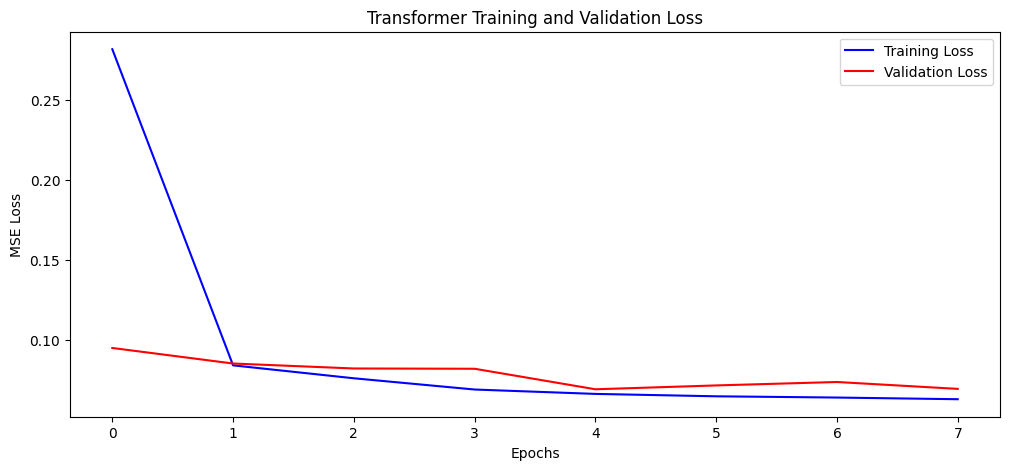

In [40]:
plt.figure(figsize=(12, 5))

plt.plot(transformer_history.history['loss'], color='blue', label='Training Loss')
plt.plot(transformer_history.history['val_loss'], color='red', label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Transformer Training and Validation Loss')
plt.legend()

plt.show()

In [52]:
sample_index = 6513

actual = y_val[sample_index]
pred_transformer_scaled = transformer_model(x_val_transformer[sample_index: sample_index+1], training=False)
pred_transformer = pred_transformer_scaled.numpy()[0] * train_std + train_mean

print('Actual Demands:', actual)
print('Transformer Prediction:', pred_transformer)

Actual Demands: [41658. 41241. 41014. 41299. 42023. 44915. 48779. 51364. 54312. 57106.
 60157. 62732. 65293. 66881. 66784. 64627. 61209. 58477. 55672. 52517.
 49454. 46474. 44463. 42590.]
Transformer Prediction: [42133.3125059  42008.7343809  42219.01514262 43297.65918559
 44884.77979106 46918.57695598 49884.93359965 53028.41113872
 56162.567877   58955.00733012 61436.87158794 63603.39307231
 65063.63525981 65486.67236919 64719.12158794 63883.94971294
 62414.9819395  59587.33643169 56404.911627   53579.52979106
 50517.0534727  47343.56732768 45780.54175395 44440.70166606]


In [53]:
y_val_pred_transformer_scaled = transformer_model(x_val_transformer, training=False)
y_val_pred_transformer = y_val_pred_transformer_scaled.numpy() * train_std + train_mean

print(y_val.shape)
print(y_val_pred_transformer.shape)

(8761, 24)
(8761, 24)


In [54]:
val_transformer_mae = np.abs(y_val_pred_transformer - y_val).mean()
val_transformer_rmse = np.sqrt(np.square(y_val_pred_transformer - y_val).mean())
normalized_val_transformer_mae = (val_transformer_mae / y_val.mean()) * 100

In [55]:
print('Validation MAE:', val_transformer_mae)
print('Validation RMSE:', val_transformer_rmse)
print('Normalized Validation MAE:', normalized_val_transformer_mae)

Validation MAE: 1967.1574926041876
Validation RMSE: 2822.3921086529244
Normalized Validation MAE: 3.7243673991934116


## Validation Performance Comparison

In [56]:
# LSTM model

lstm_model = keras.models.load_model('gridcast_lstm_v1.keras')
lstm_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 168, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,370 (216.29 KB)

 Trainable params: 18,456 (72.09 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 36,914 (144.20 KB)

In [58]:
x_val_lstm = x_val_scaled[:, :, np.newaxis]

y_val_pred_lstm_scaled = lstm_model(x_val_lstm, training=False)
y_val_pred_lstm = y_val_pred_lstm_scaled.numpy() * train_std + train_mean

val_lstm_mae = np.abs(y_val_pred_lstm - y_val).mean()
val_lstm_rmse = np.sqrt(np.square(y_val_pred_lstm - y_val).mean())
normalized_val_lstm_mae = (val_lstm_mae / y_val.mean()) * 100

In [59]:
print('Validation MAE:', val_lstm_mae)
print('Validation RMSE:', val_lstm_rmse)
print('Normalized Validation MAE:', normalized_val_lstm_mae)

Validation MAE: 2018.0572559186885
Validation RMSE: 2929.8494826964643
Normalized Validation MAE: 3.8207345786530644


In [60]:
# Daily Seasonal Baseline

y_val_predict_daily = x_val[:, -24: ]

val_daily_mae = np.abs(y_val_predict_daily - y_val).mean()
val_daily_rmse = np.sqrt(np.square(y_val_predict_daily - y_val).mean())
normalized_val_daily_mae = (val_daily_mae / y_val.mean()) * 100

In [61]:
# MAE and RMSE Summary

validation_model_results = pd.DataFrame(
    {
        'Model': ['Daily Seasonal Baseline', 'LSTM', 'Transformer'],
        'MAE (MW)' : [val_daily_mae, val_lstm_mae, val_transformer_mae],
        'RMSE (MW)' : [val_daily_rmse, val_lstm_rmse, val_transformer_rmse],
        'Normalized MAE (%)': [normalized_val_daily_mae, normalized_val_lstm_mae, normalized_val_transformer_mae]
    }
)

validation_model_results.round(2)

,Model,MAE (MW),RMSE (MW),Normalized MAE (%)
0,Daily Seasonal Baseline,2353.57,3402.53,4.46
1,LSTM,2018.06,2929.85,3.82
2,Transformer,1967.16,2822.39,3.72


In [62]:
transformer_model.save("gridcast_transformer_v1.keras")
transformer_history_df = pd.DataFrame(transformer_history.history)
transformer_history_df.to_csv("transformer_training_history_v1.csv",index=False)

In [63]:
# Transformer MAE by Horizon

val_transformer_mae_by_horizon = np.abs(y_val_pred_transformer - y_val).mean(axis=0)
val_transformer_mae_by_horizon

array([ 931.10045666, 1123.01674339, 1261.56529883, 1432.14414368,
       1564.73137426, 1681.68214113, 1785.21491407, 1890.15570151,
       1973.78842871, 2077.75342639, 2057.42216632, 2126.53787703,
       2148.91599718, 2165.21270013, 2190.26598003, 2191.63204769,
       2268.3747637 , 2250.56302191, 2303.91439392, 2324.33438996,
       2309.57018859, 2366.88901026, 2350.24389532, 2436.75076182])

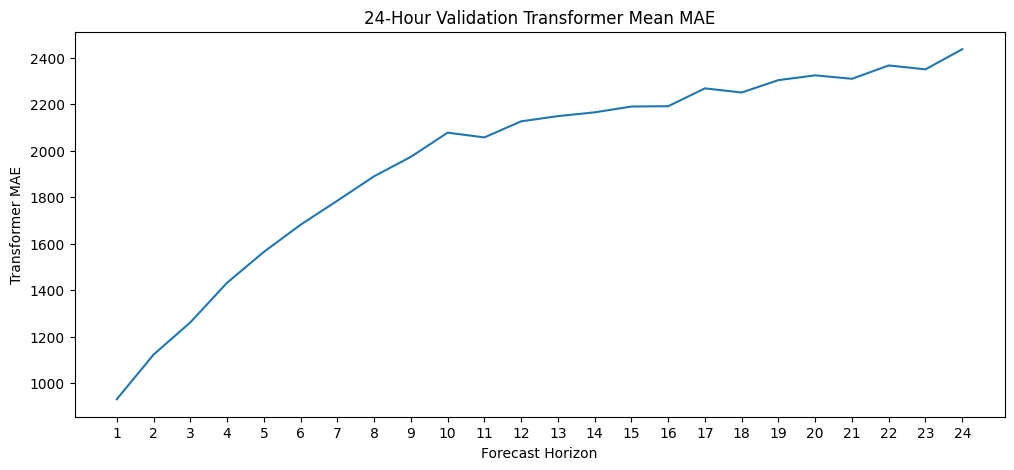

In [64]:
hours_ahead = np.arange(1, 25)

plt.figure(figsize=(12, 5))
plt.plot(hours_ahead, val_transformer_mae_by_horizon)
plt.xlabel('Forecast Horizon')
plt.ylabel('Transformer MAE')
plt.title('24-Hour Validation Transformer Mean MAE')
plt.xticks(range(1, 25))
plt.show()

Horizon-Wise Validation Performance

The Transformer validation MAE generally increases as the forecast horizon becomes longer, reflecting the greater uncertainty associated with predicting further into the future. Compared with the LSTM, the Transformer performs worse for the first few forecast hours, with the LSTM showing a clear advantage at very short horizons. However, the Transformer catches up around the fourth forecast hour and achieves lower MAE across most of the remaining 24-hour horizon. This helps explain why the Transformer obtains a slightly lower overall validation MAE than the LSTM despite weaker short-term performance. Since both models predict all 24 hours simultaneously, the increasing error with forecast horizon should be interpreted as decreasing predictive information for more distant hours rather than recursive error accumulation.

In [72]:
sample_index = 6513

actual = y_val[sample_index]
pred_daily = y_val_predict_daily[sample_index]
pred_lstm = y_val_pred_lstm[sample_index]
pred_transformer = y_val_pred_transformer[sample_index]

print('Actual Demands:', actual)
print('Daily Seasonality Prediction:', pred_daily)
print('LSTM Prediction:', pred_lstm.round(2))
print('Transformer Prediction:', pred_transformer.round(2))

Actual Demands: [41658. 41241. 41014. 41299. 42023. 44915. 48779. 51364. 54312. 57106.
 60157. 62732. 65293. 66881. 66784. 64627. 61209. 58477. 55672. 52517.
 49454. 46474. 44463. 42590.]
Daily Seasonality Prediction: [42048. 41683. 42589. 44386. 45351. 47949. 50911. 52543. 54805. 57546.
 60602. 63313. 65032. 66352. 66140. 63859. 60609. 57917. 55125. 52203.
 49616. 46778. 44601. 42780.]
LSTM Prediction: [42426.33 42066.98 42366.76 43418.71 45050.09 46938.25 49705.01 52719.54
 55860.35 58721.73 61073.03 63483.43 64312.11 64196.71 63931.86 62946.27
 61010.39 58641.08 55979.98 52730.42 50070.69 47817.15 45451.91 43653.53]
Transformer Prediction: [42133.31 42008.73 42219.01 43297.66 44884.78 46918.58 49884.93 53028.41
 56162.57 58955.01 61436.87 63603.4  65063.64 65486.67 64719.12 63883.95
 62414.98 59587.34 56404.91 53579.53 50517.05 47343.57 45780.54 44440.7 ]


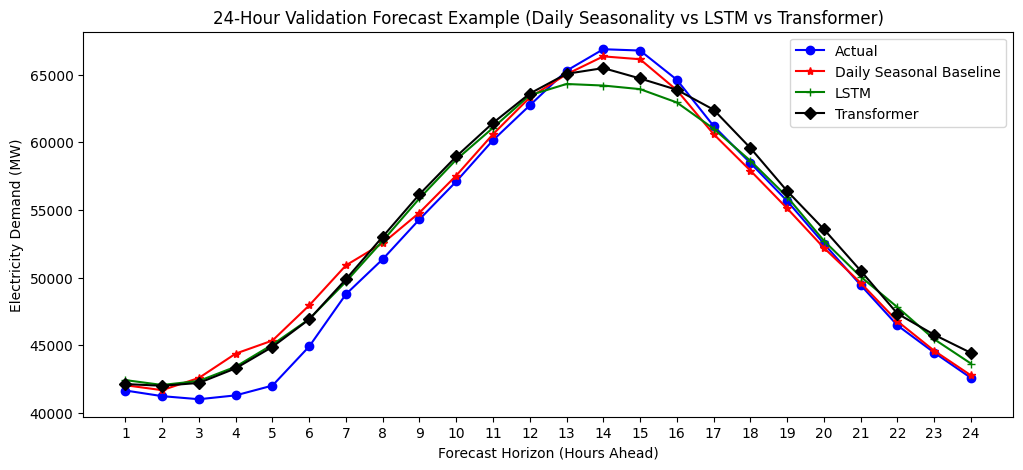

In [73]:
hours_ahead = np.arange(1, 25)

plt.figure(figsize=(12, 5))

plt.plot(hours_ahead, actual, color='blue', marker='o', label='Actual')
plt.plot(hours_ahead, pred_daily, color='red', marker='*', label='Daily Seasonal Baseline')
plt.plot(hours_ahead, pred_lstm, color='green', marker='+', label='LSTM')
plt.plot(hours_ahead, pred_transformer, color='black', marker='D', label='Transformer')

plt.xlabel('Forecast Horizon (Hours Ahead)')
plt.ylabel('Electricity Demand (MW)')
plt.title('24-Hour Validation Forecast Example (Daily Seasonality vs LSTM vs Transformer)')
plt.xticks(range(1, 25))
plt.legend()

plt.show()

Forecast Example Interpretation

All three models capture the overall daily demand pattern in this validation example, including the morning increase, daytime peak, and subsequent decline. The LSTM and Transformer produce smooth forecasts that follow the general shape of the observed demand, while the daily seasonal baseline remains highly competitive for this particular 24-hour period.

Although the Transformer achieves the lowest overall MAE, RMSE, and normalized MAE across the full 2024 validation set, it does not necessarily outperform the other models for every individual forecasting window. This example illustrates why model performance should be evaluated using aggregate validation metrics rather than a single forecast period.